# **Sequências usando RNNs e CNNs**

## **Motivação**

Redes feedforward passam informação em uma única direção: input → camadas → output. Isso funciona bem quando os dados são **independentes** entre si (ex: classificar imagens), mas falha quando existe **dependência sequencial**, prever x sem o contexto de x-1, x-2... é uma desvantagem.

**Exemplo:** em "O moço viu um carro e não atravessou a ___", só sabemos que a resposta é "rua" com o contexto das palavras anteriores e além disso se uma palavra ali troca de posicao tudo muda.

*Vamos usar todo o passado como input entao?*  Sequências têm tamanhos variáveis e passados longos tornam o input inviável.

*resumir o passado com estatísticas (média, moda, mediana...) ?*
Funciona, mas tem limitações:
- **Perde a ordem** dos eventos (ex: [1,2,10] e [10,2,1] têm a mesma média, mas são sequências opostas) 
- Informacao muito antiga pode **enviesar as estatisticas**
- Exige **feature engineering manual** (descobrir na mão o que importa)

→ Troca **capacidade de captar padrões complexos** por **simplicidade/interpretabilidade**.

Ai entra RNNs que criam uma **memória dos inputs anteriores**, armazenada como parâmetros da rede, aprendida automaticamente, sem feature engineering manual. Elas trabalham com sequencias, se antes uma instancia/exemplo era representado por *m* colunas de features, agora uma instancia é representada por *m* vetores (sequencias temporais) de tamanho max_len, ou seja, *m* caracteristicas e suas evoluções e *max_len* timesteps.

## **Neuronios recorrentes e camadas**

A entrada de uma camada recorrente tem sempre 3 dimensões sendo elas [seq_len, batch_size, n_features] por padrão do pytorch e [batch_size, seq_len, n_features] caso o parametro *batch_first = True*. Sendo cada uma dessas dimensões:

- **batch_size:** tamanho do batch da epoca (quantas instancias considerar para cada atualizacao dos parametros em uma epoca)
    - Um exemplo seria 12 clientes computados por vez para computar o gradiente
- **seq_len:** tamanho maximo das sequencias de uma instancia, ou seja, tamanho maximo de passos no tempo
    - Um exemplo seria 12 meses/passos de histórico de cada cliente
    - Em sequencias de tamanho variado, uma vez definido o max_len, todas as sequencias que forem menores que max_len são completadas com padding que são valores artificiais que permitem todas as instancias caberem em um unico tensor comportado. A *função pack_padded_sequence(...)* é uma técnica de otimização que informa à LSTM exatamente onde cada sequência termina, para que ela ignore o padding e não "aprenda" com dados falsos.
- **n_features (input_size):** quantas variaveis existem a cada passo de tempo 
    - Um exemplo seria 3 caracteristicas do cliente em cada mes como gastos, chamadas e usos

Dentro dessa camada existem *hidden_size* neurônios, cada um deles recebe 2 vetores de entrada e tem 2 vetores de pesos:

- ${x_t}$: Vetor de features de uma instancia no tempo t, ou seja, os valores das series temporais no tempo t de dimensão = ${1 * n_{input}}$. Ao concatenar todas as instancias do mini-batch temos uma matriz ${X_t}$ de dimensao ${n_{batch} * n_{input}}$
- ${y_{t-1}}$: Vetor de saidas do timestep anterior (uma saida por neuronio) de dimensão = ${1 * n_{neuronios}}$. Ao concater a saida de todas as instancias do batch temos uma matriz ${Y_{t-1}}$ de dimensao ${n_{batch} * n_{neuronios}}$
- ${w_x}$: Vetor de pesos do input de dimensão = ${1 * n_{input}}$. Ao concatenar verticalmente os vetores de pesos de todos os neuronios temos uma matriz ${W_x}$ de dimensao ${n_{neuronios} * n_{input}}$
- ${w_{y_{t-1}}}$:Vetor de pesos do timestep anterior de dimensão = ${1 * n_{neuronios}}$. Ao concatenar veticalmente os pesos de todos os neuronios temos uma matriz ${W_{y_{t-1}}}$ de dimensao ${n_{neuronios} * n_{n_neuronios}}$

A saida de um timestep t é definida como:

- Para uma unica instancia x no tempo t:

$$
\begin{equation}
\mathbf{y}_{(t)} = \phi\left( \mathbf{W}_x^T \mathbf{x}_{(t)} + \mathbf{W}_{\hat{y}}^T \hat{\mathbf{y}}_{(t-1)} + \mathbf{b} \right)
\end{equation}
$$

- Para uma mini-batch inteiro no tempo t (as matrizes ainda podem ser concatenadas e feitas em uma unica operacao):

$$
\begin{equation}
\hat{\mathbf{Y}}_{(t)} = \phi\left( \mathbf{X}_{(t)} \mathbf{W}_x + \hat{\mathbf{Y}}_{(t-1)} \mathbf{W}_{\hat{y}} + \mathbf{b} \right)
\end{equation}
$$

Uma instancia de treino do batch é um conjunto de n_features que sao vetores de tamanho seq_len (timesteps). Para cada camada recorrente as sequencias sao entregues um timestep por vez (todas as n_features daquele timestep) do menor para o maior, ou seja, 0 -> 1 -> ...-> seq_len (no timestep 0, o output anterior geralmente é zerado).

### **Celulas de memoria**

Como a saida de um ou mais neuronios no timestep t é uma funcao de todos os timesteps anteriore, chamamos isso de celulas de memória. Uma celula com apenas um ou mais neuronios é a forma mais simples possivel de RNN e por isso tem uma capacidade limitada de aprendizado temporal (uns 10 timesteps em media antes de perder qualidade), existem camadas mais complexas como GRU e LSTM que extendem essa memória. O estado de uma celula no tempo t é chamado de ${h_t}$ que é uma funcao ${f(x_t , h_{t-1})}$, para a RNN mais ismples esse estado é simplesmente a saida do timestep mas em camadas mais complexas isso nao é mais verdade.

### **Input e Output**

A entrada e saida de camadas recorrentes podem variar muito dependendo do objetivo:

- **sequence to sequence:** cada timestep tem uma saida individual ${y_{t}}$, a loss é computada usando a saida de todos os timestamps. Util para coisas como: prever t+1 dado os t anteriores (isso poderia ser modelado apenas gerando o ultimo t mas fazendo desse jeito temos mais sinal de erro)
- **sequence to vector:** mesma sequência de entrada, mas agora a rede ignora as saídas intermediárias, só a última importa. É o caso do sentiment analysis: você lê a sequência inteira, e só no final decide "bom" ou "ruim".
- **vector to sequence:** entra com um único vetor (repetido em cada timestep) e a rede gera uma sequência inteira. É o caso de image captioning: uma imagem vira um vetor (via CNN), e esse vetor "alimenta" a RNN em todos os passos pra gerar uma legenda palavra por palavra.
- **encoder-decoder:** primeiro um encoder (seq-to-vector) comprime a sequência de entrada num único vetor, depois um decoder (vector-to-sequence) usa esse vetor pra gerar a sequência de saída. É o caso de tradução em que ler toda a frase primeiro é importante.

![image.png](imagens/rnn_tipos.png)

## **Treino de RNNs**

O estado no timestep t depende de todos os estados anteriores a t, ou seja, é uma função composta, da mesma forma que em redes densas a saída final nada mais é que uma composição das saídas das camadas anteriores. A diferença chave é que, numa RNN, essa composição acontece no tempo, não em profundidade: é como se cada timestep fosse "desenrolado" (unrolled) numa camada própria, mas compartilhando os mesmos pesos (Wx, Wŷ, b) em todos os passos. Podemos usar Backpropagation Through Time (BPTT) para atualizar os pesos, levando em consideração essa dependência temporal. O processo tem duas etapas:

- *Forward pass:* a rede processa a sequência inteira, timestep a timestep, gerando uma saída y(t) em cada passo.
- *Backward pass:* como todas as saídas dependem (direta ou indiretamente) dos mesmos pesos compartilhados, o gradiente de cada timestep se acumula, soma-se o gradiente de todos os passos antes de fazer uma única atualização dos pesos.

Dependendo da tarefa, nem todos os outputs dos timesteps entram na loss. Mas, mesmo quando só a última saída importa, o gradiente ainda precisa percorrer toda a cadeia de timesteps anteriores (porque y(N) depende de y(N-1), que depende de y(N-2)...), então o custo computacional do BPTT continua proporcional ao comprimento da sequência Além disso, para sequências muito longas, BPTT completo fica caro e sofre de vanishing/exploding gradients (o gradiente precisa atravessar muitos passos multiplicativos). Na prática, usa-se truncated BPTT, limita-se o número de timesteps que o gradiente propaga pra trás, mesmo que a sequência de entrada seja mais longa.

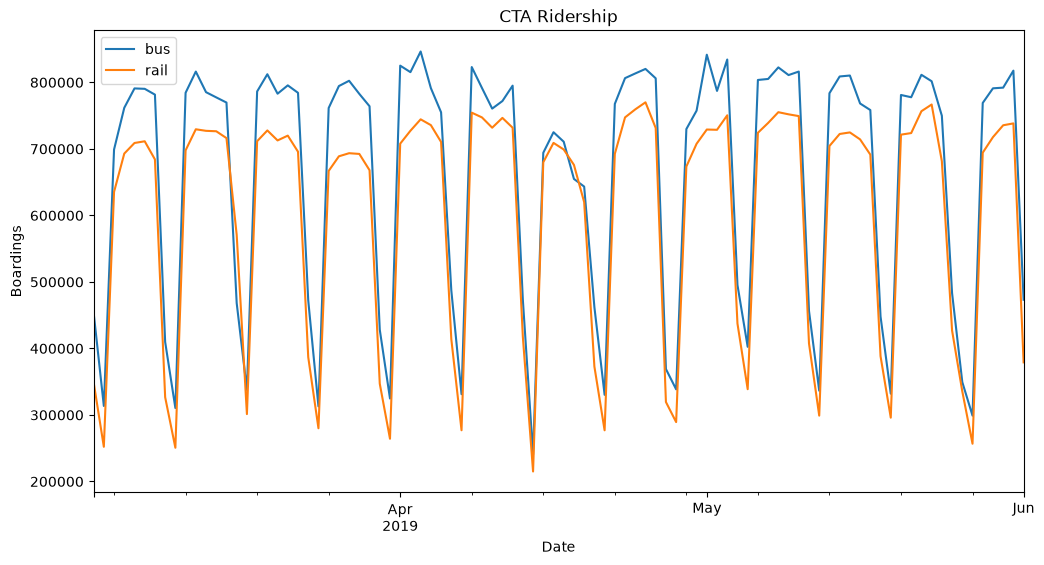

In [7]:
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from pathlib import Path

path = Path("data/CTA_-_Ridership_-_Daily_Boarding_Totals_20250830.csv")
df = pd.read_csv(path, parse_dates=["service_date"])
df.columns = ["date", "day_type", "bus", "rail", "total"] 
df = df.sort_values("date")
df = df.drop("total", axis=1) 
df = df.drop_duplicates()
df["bus"] = df["bus"].str.replace(",", "", regex=False)
df["rail"] = df["rail"].str.replace(",", "", regex=False)
df = df.astype({"bus": "int", "rail": "int"})
df.set_index('date')

subset = df[(df['date'] > '2019-03') & (df['date'] <= '2019-06')].set_index("date")
ax = subset.plot(y=["bus", "rail"], title="CTA Ridership", ylabel="Boardings", xlabel="Date", figsize=(12, 6))
plt.show()

Esse é um dataset com numero de passageiros diariamente em onibus e trem.Series temporais geralmente sao classificadas em 2 formas de acorco com o numero de features:

- **Univariada:** Temos apenas uma variavel durente os timesteps
- **Multivariada:** é o caso desse dataset em que temos varias informacoes por timestep (onibus e trem)

A forma mais simples fazer uma predicao de valor futuro (forecasting) no tempo t é copiando valores observados anteriormente em dadas proximas, por exemplo o dia anterior, o mesmo dia da semana passada, mesmo dia do mes passado e etc. Como é possivel ver padroes muito parecidos se repetem de semana em semana, isso sigficia que existe uma sazonalidade semanal ali.

- **Sazonalidade (seasonality):** Padroes iguais ou muito proximos que se repetem entre intervalos de tempo fixos como dia, semana, mes, ano e etc.
- **Tendencia (Tendency):** Quedas ou aumentos constantes que vem acontecendo sequencialmente de tempo em tempo.

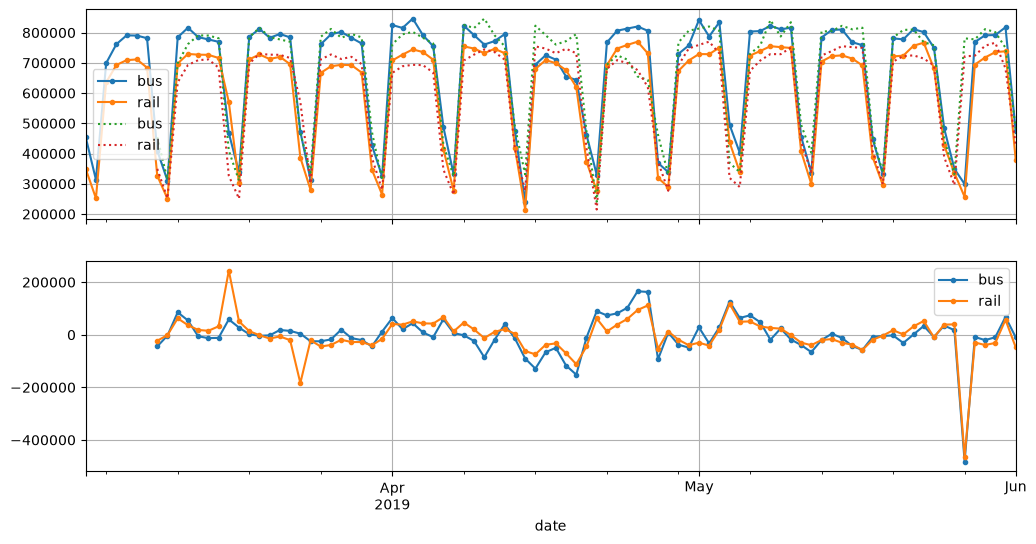

In [8]:
diff_7 = subset[["bus", "rail"]].diff(7)
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
subset.plot(ax=axs[0], legend=True, marker=".") # real
subset.shift(7).plot(ax=axs[0], grid=True, legend=True,linestyle=":") # previsao
diff_7.plot(ax=axs[1], grid=True, marker=".") # erro de previsao
plt.show()

Existe uma outra métrica de erro de predicao além de MAE e MSE. Se chama **MAPE (Mean Absolute Percentage Error)** e é definida como:

$$\text{MAPE} = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

Que é basicamente quanto porcento em média estamos errando em cada predicao. Ou seja, calculamos o erro, olhamos quanto porcento/vezes ele variou do correto, somamos essa variacao e tiramos a media. Ele tem duas principais vantagens:

- **Interpretabilidade:** Agora o erro nao é mais x unidades da unidade analisada, como MAE = 10 lidando com dinheiro significa que em media o modelo esta errando em 10 reais. O MAPE = 10 significa que o modelo esta errado em média 10% em relacao ao correto e isso é mais facil de interpretar.
- **Comparabilidade:** Como é adimensional (não depende da unidade de medida), o MAPE permite comparar a acurácia de modelos aplicados a variáveis com escalas totalmente diferentes, por exemplo, comparar a previsão de vendas (em milhares de reais) com a previsão de temperatura (em graus).

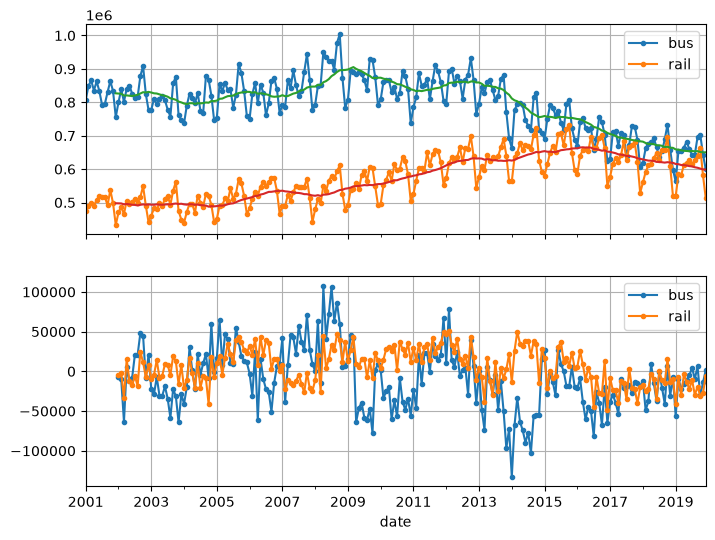

In [9]:
period = slice("2001", "2019")
df_monthly = df.set_index("date").select_dtypes(include="number").resample("ME").mean()
rolling_average_12_months = df_monthly.loc[period].rolling(window=12).mean()

fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
df_monthly.loc[period].plot(ax=axs[0], marker=".")
rolling_average_12_months.plot(ax=axs[0], grid=True, legend=False)
df_monthly.diff(12).loc[period].plot(ax=axs[1], grid=True, marker=".")
plt.show()

Antes ambas as series temporais tinham sua sazonalidade anual e sua tendencia. É dificil prever valores em series assim pois a variabilidade é alta... para isso existe uma técnica chamada:

- **Diferenciacao (Differecing):** Consiste em subtrair da a serie no timestep t, o valor da serie no timestep t-s, sendo s a duracao da sazonalidade (s pode ser 1 também), ou seja, estamos subtraindo uma season de outra, se elas iguais ou parecidas o resultado é uma nova série temporal centralizada e mais comportada. Essa serie é chamada de serie estacionária. Essa tecnica remove sazonalidade e tendencias da serie original tornando agora uma serie muito mais facil de prever, depois só traduzir as previsoes de volta. 

    - **Serie estacionária:** Series que tem media (centro) e variancia fixos durante todos os timesteps t (todo tempo).

## **Modelos estatisticos para forecasting**

Existem metodos estatísticos sem ML que geralmente são usados para fazer forecasting. Os principais modelos são os da familia ARMA que trabalham com médias moveis ponderando o timestep e erro com pesos que são obtidos através de OLS (regressão linear) que minimiza o erro quadratico ou maximização da verossimilhança.

- **ARMA (autoregressive moving average):** Uma predição do timestep *t* é uma soma das *p* predições *y_i* anteriores ponderadas por pesos *a_i* + soma dos *q* erros de predição anteriores ponderados pelos pesos *o_i*.
    - **Premissa:** A série predita é estacionária uma vez que os pesos que ponderam o erro e predições passadas são constantes e portanto só funcionam se o comportamento para qualquer t é parecido, ou seja, media e desvio parecidos. Além disso, é uma ponderação linear e portanto só captura padrões lineare.

$$ \hat{y}_{t} = \sum_{i=1}^{p} \alpha_i y_{t-i} + \sum_{i=1}^{q} \theta_i \varepsilon_{t-i} \quad \text{com} \quad \varepsilon_{t} = y_{t} - \hat{y}_{t} $$

- **ARIMA (autoregressive integrated moving average):** Resolve o problema da série não-estacionária através de um parametro *d* que diz quantas diferenciacoes vamos fazer na série. Por exemplo, se temos uma série com tendencia quadratica, se diferenciarmos ela 2x (d=2), ela fica estacionária e assim por diante.

- **SARIMA (Seasonal ARIMA):** Essa versão adiciona informação de sazonalidade na predição (parametros dado que conhecemos a sazonalidade)


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

origin, today = "2019-01-01", "2019-05-31"
rail_series = df.set_index("date").loc[origin:today]["rail"].asfreq("D")
model = ARIMA(rail_series, order=(1, 0, 0), seasonal_order=(0, 1, 1, 7)) # order=(p,d,q) e seasonal_order()
model = model.fit()
y_pred = model.forecast()
y_pred

2019-06-01    427758.626221
Freq: D, dtype: float64

In [ ]:
origin, start_date, end_date = "2019-01-01", "2019-03-01", "2019-05-31"
time_period = pd.date_range(start_date, end_date)
rail_series = df.set_index("date").loc[origin:today]["rail"].asfreq("D")
y_preds = []
for today in time_period.shift(-1):
    model = ARIMA(rail_series[origin:today], # minimiza os pesos com os timesteps anteriores e prediz o "hj"
    order=(1, 0, 0),
    seasonal_order=(0, 1, 1, 7))
    model = model.fit() # tem que minimizar e encontrar os parametros para cada predição

    y_pred = model.forecast().iloc[0]
    y_preds.append(y_pred)
y_preds = pd.Series(y_preds, index=time_period)
mae = (y_preds - rail_series[time_period]).abs().mean() 

print(f"MAE (SARIMA): {mae}")

MAE (SARIMA): 32040.720080694857


## **Implementando a RNN**

Primeiro é necessário preparar os dados: 

- *Para cada timestep t vamos pegar 8 semanas anteriores de dias (56 dias), ou seja, 56 timesteps [t-55,t] para prever t+1. Ou seja, para uma serie [1,2,3,4] e uma janela de tamanho 2 vamos gerar as seguintes instancias de treino (x,y): [([1,2],[3]), ([2,3],[4])]*

Para isso é preciso criar um Dataset do torch que tem a responsabilidade de dados, criar as instancias de treino. Depois criar o DataLoader que dado o dataset tem a responsabilidade de separar as instancias em batchs, fazer shuffle e outras coisinhas se necessário.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TimeSeriesDataset(Dataset):

    def __init__(self, series, window_len):
        self.series = series
        self.window_len = window_len

    def __len__(self):
        return len(self.series) - self.window_len

    def __get_item__(self, idx):

        end = idx + self.window_len 
        window = self.series[idx:end]
        target = self.series[end]

        return window, target

my_serie = torch.tensor([[1,5], [2,6], [3,7], [4,8]]) # em que cada linha é um timestep e coluna é feature
my_dataset = TimeSeriesDataset(series=my_serie, window_len=2)

for window, target in my_dataset:

    print(f"Window: {window} Target: {target}")

loader = DataLoader(my_dataset, batch_size=1, shuffle=True)
for x, y in loader:

    print(f"x: {x} y: {y}")
    

## **premissas**

